Student Name: Deepak Sindhu

Student ID: GH1056312

Module: M505 Introduction to AI and Machine Learning

University: GISMA University of Applied Sciences




** 1. Introduction**

    Digital marketing plays an important role in helping banks to sell their financial products such as term deposits. However, contacting customers without understanding their interests  increase costs and reduce campaign effectiveness. Machine learning can help banks analyse customer data and to predict customer behaviour. This project uses the Bank Marketing Dataset to develop a machine learning pipeline for predicting whether a customer will subscribe to a term deposit. The project includes data exploration, preprocessing, feature preparation, model training, hyperparameter tuning and evaluation using Scikit-learn techniques to identify the most effective classification approach.
    
    **Machine Learning Problem:** This is a binary classification problem.

    **Objective/Motivation:** is to predict whether a customer will subscribe to a term deposit after being contacted during a marketing campaign.

    Dataset Name: Bank Marketing Dataset

    Dataset Source: UCI Machine Learning Repository

    Dataset Link: https://archive.ics.uci.edu/ml/datasets/bank+marketing
    Alternative OpenML Dataset: https://www.openml.org/d/1461

    License: Public Research Dataset

    Machine Learning Task: Binary Classification

    Number of Records: 45,211
    Number of Features: 16 Input Features

    1 Target Variable

    Target Variable: y
    Values:  yes, no

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split

In [2]:
# Load Dataset and dataset colletction
df = pd.read_csv("bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
df.shape

(45211, 17)

In [4]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
# Missing Values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [7]:
# check duplicate
df.duplicated().sum()

np.int64(0)

In [8]:
# descriptive statistics
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [9]:
# Display the frequency of each class
target_counts = df["y"].value_counts()

print(target_counts)

y
no     39922
yes     5289
Name: count, dtype: int64


In [10]:
# Display class percentages
target_percentage = (df["y"].value_counts(normalize=True) * 100).round(2)

print(target_percentage)

y
no     88.3
yes    11.7
Name: proportion, dtype: float64


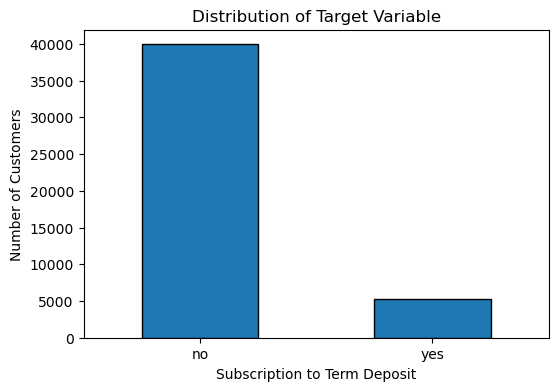

In [11]:
# bar chart
plt.figure(figsize=(6,4))

df["y"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Target Variable")
plt.xlabel("Subscription to Term Deposit")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.show()